In [1]:
import pandas as pd

# Charger les fichiers de données
file_path1 = "players_stats_by_season_full_details.xlsx"
file_path2 = "NBA_Anthropometric.csv"

df1 = pd.read_excel(file_path1)
df2 = pd.read_csv(file_path2)

# Afficher les deux DataFrames
display(df1.head())
display(df2.head())

,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,...,birth_date,height,height_cm,weight,weight_kg,nationality,high_school,draft_round,draft_pick,draft_team
0,NBA,1999 - 2000,Regular_Season,Shaquille O'Neal,LAL,79,3163.0,956,1665,0,...,"Mar 6, 1972",2025-01-07 00:00:00,216.0,325.0,147.0,United States,Robert G. Cole High School,1.0,1.0,Orlando Magic
1,NBA,1999 - 2000,Regular_Season,Vince Carter,TOR,82,3126.0,788,1696,95,...,"Jan 26, 1977",2025-06-06 00:00:00,198.0,220.0,100.0,United States,Mainland High School,1.0,5.0,Golden State Warriors
2,NBA,1999 - 2000,Regular_Season,Karl Malone,UTA,82,2947.0,752,1476,2,...,"Jul 24, 1963",2025-09-06 00:00:00,206.0,265.0,120.0,United States,Summerfield High School,1.0,13.0,Utah Jazz
3,NBA,1999 - 2000,Regular_Season,Allen Iverson,PHI,70,2853.0,729,1733,89,...,"Jun 7, 1975",6-0,183.0,165.0,75.0,United States,Bethel High School,1.0,1.0,Philadelphia Sixers
4,NBA,1999 - 2000,Regular_Season,Gary Payton,SEA,82,3425.0,747,1666,177,...,"Jul 23, 1968",2025-04-06 00:00:00,193.0,180.0,82.0,United States,Skyline High School,1.0,2.0,Seattle SuperSonics


,player_name,position,height,height_with_shoes,weight,wingspan,standing_reach,body_fat_percentage,hand_length,hand_width,draft_year
0,Trey Alexander,SG,191.14,NaN,83.73,208.28,257.81,NaN,21.59,22.22,2023
1,Amari Bailey,SG,191.14,NaN,86.55,200.66,262.89,NaN,20.32,23.50,2023
2,Emoni Bates,SF,203.84,NaN,81.28,205.74,266.70,NaN,20.32,20.96,2023
3,Reece Beekman,PG,186.69,NaN,86.45,200.66,255.27,NaN,21.59,20.96,2023
4,Anthony Black,PG,197.48,NaN,95.25,201.93,260.35,NaN,20.96,24.13,2023


In [2]:
# Extraire les noms uniques de df2
noms_uniques_df2 = set(df2['player_name'].unique())

# Extraire les noms uniques de df1
noms_uniques_df1 = set(df1['Player'].unique())

# Trouver combien de noms uniques de df2 sont présents dans df1
noms_communs = noms_uniques_df2.intersection(noms_uniques_df1)
print(f"Nombre de noms uniques de df2 présents dans df1 : {len(noms_communs)}")

Nombre de noms uniques de df2 présents dans df1 : 947


In [3]:
# Filtrer df1 pour ne garder que les lignes dont le nom du joueur est dans noms_communs
df1_trie = df1[df1['Player'].isin(noms_communs)]
#display(df1_trie.head())
df1_trie.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6269 entries, 42 to 53787
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   League       6269 non-null   object 
 1   Season       6269 non-null   object 
 2   Stage        6269 non-null   object 
 3   Player       6269 non-null   object 
 4   Team         6269 non-null   object 
 5   GP           6269 non-null   int64  
 6   MIN          6269 non-null   float64
 7   FGM          6269 non-null   int64  
 8   FGA          6269 non-null   int64  
 9   3PM          6269 non-null   int64  
 10  3PA          6269 non-null   int64  
 11  FTM          6269 non-null   int64  
 12  FTA          6269 non-null   int64  
 13  TOV          6269 non-null   int64  
 14  PF           6269 non-null   int64  
 15  ORB          6269 non-null   int64  
 16  DRB          6269 non-null   int64  
 17  REB          6269 non-null   int64  
 18  AST          6269 non-null   int64  
 19  STL      

In [4]:
#tri sur la ligue NBA
df1_trie_NBA = df1_trie[df1_trie['League'] == 'NBA']
#df1_trie_NBA.info()
#display(df1_trie_NBA.head())
#display(df1_trie_NBA.tail())

In [5]:
# Compter les joueurs uniques dans la ligue NBA après le tri
liste_trie_NBA_uniqueplayer = df1_trie_NBA['Player'].unique()
print(f"il y a {len(liste_trie_NBA_uniqueplayer)} joueurs uniques dans la ligue NBA après le tri.")

il y a 493 joueurs uniques dans la ligue NBA après le tri.


In [6]:
import unicodedata
#normalise les noms pour une meilleure correspondance
def normalize_name(s):
    if pd.isna(s):
        return s
    s = str(s).lower().strip()
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = s.replace('.', '').replace("'", '').replace('-', ' ')
    s = ' '.join(s.split())
    return s

# create normalized name columns
df1['player_norm'] = df1['Player'].apply(normalize_name)
df2['player_norm'] = df2['player_name'].apply(normalize_name)

# optional: reduce duplicates in df2 if there are multiple anthropometric rows per player
df2_unique = df2.drop_duplicates(subset=['player_norm']).copy()

# perform inner merge on normalized names (keeps only players present in both)
merged = pd.merge(df1, df2_unique, on='player_norm', how='inner', suffixes=('_stats','_anthro'))

# drop helper column if you don't want it
# merged = merged.drop(columns=['player_norm'])

# inspect results
print(f"Merged rows: {len(merged)}")
display(merged.head())

# save merged dataset
merged.to_csv('merged_players_stats_anthro.csv', index=False)

Merged rows: 6366


,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,...,position,height_anthro,height_with_shoes,weight_anthro,wingspan,standing_reach,body_fat_percentage,hand_length,hand_width,draft_year
0,NBA,1999 - 2000,Regular_Season,Glen Rice,LAL,80,2530.0,421,980,84,...,SF/SG,194.31,197.48,95.62,206.38,257.81,8.45,21.59,22.86,2013
1,NBA,1999 - 2000,Regular_Season,Jaren Jackson,SAS,81,1691.0,186,488,108,...,PF/C,207.64,211.46,107.05,226.70,279.40,7.20,25.40,25.40,2018
2,NBA,1999 - 2000,Playoffs,Glen Rice,LAL,23,766.0,93,228,28,...,SF/SG,194.31,197.48,95.62,206.38,257.81,8.45,21.59,22.86,2013
3,Euroleague,2000 - 2001,International,Marko Jaric,BOL,22,631.3,79,180,17,...,SG/SF,199.39,NaN,95.25,205.74,264.16,NaN,NaN,NaN,2000
4,Euroleague,2000 - 2001,International,Igor Rakocevic,BUD,11,327.9,50,120,10,...,PG,189.23,NaN,83.46,196.22,254.00,NaN,NaN,NaN,2000


In [7]:
#cleaning data, on supprime les colonnes height_stats, birth_month birth_year and player_name, height_cm

cols_to_drop = ['height_stats', 'birth_month', 'birth_year', 'player_name', 'height_cm']

# drop from merged (safe: only drop columns that exist)
merged = merged.drop(columns=[c for c in cols_to_drop if c in merged.columns])

# save cleaned dataset
merged.to_csv('merged_players_stats_anthro_cleaned.csv', index=False)


In [8]:
# convertire les dates de naissance en format datetime
# Convert birth_date like "Jan 26, 2002" -> "26.01.2002"
# Vérifie si la colonne 'birth_date' existe
if 'birth_date' in merged.columns:

    # 1️⃣ Parse les dates textuelles courantes
    # Exemple : "Jan 26, 2002"
    merged['birth_date_parsed'] = pd.to_datetime(
        merged['birth_date'], 
        errors='coerce', 
        infer_datetime_format=True
    )

    # 2️⃣ Fallback pour les suffixes anglais (1st, 2nd, 3rd, 4th, ...)
    mask = merged['birth_date_parsed'].isna() & merged['birth_date'].notna()
    if mask.any():
        tmp = (
            merged.loc[mask, 'birth_date']
            .astype(str)
            .str.lower()
            .str.replace(r'(\d)(st|nd|rd|th)', r'\1', regex=True)
        )
        merged.loc[mask, 'birth_date_parsed'] = pd.to_datetime(
            tmp, 
            errors='coerce', 
            infer_datetime_format=True
        )

    # 3️⃣ Formater la colonne finale en "dd.mm.yyyy" (NaT → reste NaN)
    merged['birth_date'] = merged['birth_date_parsed'].dt.strftime('%d.%m.%Y')

    # 4️⃣ Supprimer la colonne temporaire
    merged = merged.drop(columns=['birth_date_parsed'])

    # 5️⃣ Sauvegarder le résultat
    merged.to_csv('merged_players_stats_anthro_cleaned.csv', index=False)

else:
    print("Column 'birth_date' not found in merged.")

merged['birth_date'] = pd.to_datetime(merged['birth_date'], format='%d.%m.%Y', errors='coerce')

C:\Users\J-P\AppData\Local\Temp\ipykernel_28968\3631705391.py:8: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  merged['birth_date_parsed'] = pd.to_datetime(
C:\Users\J-P\AppData\Local\Temp\ipykernel_28968\3631705391.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  merged.loc[mask, 'birth_date_parsed'] = pd.to_datetime(
C:\Users\J-P\AppData\Local\Temp\ipykernel_28968\3631705391.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please speci

In [9]:
# calcule de l'âge des joueurs
today = pd.Timestamp.today()
merged['age_actuel'] = (today - merged['birth_date']).dt.days // 365.25

# calcule de l'âge des joueurs au début de la saison


In [10]:
#calcul de l'âge au début de la saison

def calcul_age_debut_saison(merged):
    """
    Calcule l'âge du joueur au début de la saison (1er octobre de l'année de début),
    en récupérant les 4 premiers chiffres de la colonne 'Season'.
    """
    # Extraire les 4 premiers caractères (année de début)
    merged['start_year'] = (
        merged['Season']
        .astype(str)
        .str[:4]
        .str.extract('(\d{4})')  # garde uniquement les chiffres
        .astype(float)
        .astype('Int64')
    )

    # Crée la date de début de saison (1er octobre de l’année de début)
    merged['season_start_date'] = pd.to_datetime(
        merged['start_year'].astype(str) + '-10-01',
        errors='coerce'
    )

    # Calcul de l'âge au début de la saison
    merged['age_debut_saison'] = ((merged['season_start_date'] - merged['birth_date']).dt.days / 365.25).round(1)

    return merged

# Application
merged = calcul_age_debut_saison(merged)

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\J-P\AppData\Local\Temp\ipykernel_28968\3735519892.py:13: SyntaxWarning: invalid escape sequence '\d'
  .str.extract('(\d{4})')  # garde uniquement les chiffres


In [11]:
print(merged.columns)

Index(['League', 'Season', 'Stage', 'Player', 'Team', 'GP', 'MIN', 'FGM',
       'FGA', '3PM', '3PA', 'FTM', 'FTA', 'TOV', 'PF', 'ORB', 'DRB', 'REB',
       'AST', 'STL', 'BLK', 'PTS', 'birth_date', 'weight_stats', 'weight_kg',
       'nationality', 'high_school', 'draft_round', 'draft_pick', 'draft_team',
       'player_norm', 'position', 'height_anthro', 'height_with_shoes',
       'weight_anthro', 'wingspan', 'standing_reach', 'body_fat_percentage',
       'hand_length', 'hand_width', 'draft_year', 'age_actuel', 'start_year',
       'season_start_date', 'age_debut_saison'],
      dtype='object')


In [12]:
nb_nan = merged['MIN'].isna().sum()
print("Nombre de NaN dans la colonne MIN :", nb_nan)

Nombre de NaN dans la colonne MIN : 0


In [13]:
print(merged['MIN'].dtype)

float64


In [14]:
print(merged['MIN'].isnull().sum())

0


In [15]:
# extraire minutes jouées
minutes = merged['MIN']
print('temps minimum joué par un joueur',minutes.min())
print('temps maximum joué par un joueur',minutes.max())

temps minimum joué par un joueur 0.8
temps maximum joué par un joueur 3388.0


In [16]:
#créattion d'une colonne keyfactors qui est unique pour chaque ligne de merged
merged['keyfactor'] = merged.index

In [17]:
# colonnes/statistiques à normaliser par minute
stats = ['FGM','FGA','3PM','3PA','FTM','FTA','TOV','PF','ORB','DRB','REB','AST','STL','BLK','PTS']

# créer colonnes per minute
created = []
for s in stats:
    if s in merged.columns:
        merged[f'{s}_per_min'] = merged[s].astype(float) / minutes
        merged[f'{s}_per_min'] = merged[f'{s}_per_min'].round(2)
        created.append(f'{s}_per_min')

# option: remplacer NaN par 0 si vous préférez
# merged[created] = merged[created].fillna(0)

print("Colonnes créées :", created)


Colonnes créées : ['FGM_per_min', 'FGA_per_min', '3PM_per_min', '3PA_per_min', 'FTM_per_min', 'FTA_per_min', 'TOV_per_min', 'PF_per_min', 'ORB_per_min', 'DRB_per_min', 'REB_per_min', 'AST_per_min', 'STL_per_min', 'BLK_per_min', 'PTS_per_min']


In [18]:
#créer une colonne EFF_per_min (mesure de l'efficacité d'un joueur par minute jouée)

merged['EFF_per_min'] = (
    (merged['PTS_per_min'] + merged['REB_per_min'] + merged['AST_per_min'] + merged['STL_per_min'] + merged['BLK_per_min'])
    - ((merged['FGA_per_min'] - merged['FGM_per_min']) + (merged['FTA_per_min'] - merged['FTM_per_min']) + merged['TOV_per_min'])
)


In [19]:
liste_teams = merged['Team'].unique()
len(liste_teams)

351

In [20]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 62 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   League               6366 non-null   object        
 1   Season               6366 non-null   object        
 2   Stage                6366 non-null   object        
 3   Player               6366 non-null   object        
 4   Team                 6366 non-null   object        
 5   GP                   6366 non-null   int64         
 6   MIN                  6366 non-null   float64       
 7   FGM                  6366 non-null   int64         
 8   FGA                  6366 non-null   int64         
 9   3PM                  6366 non-null   int64         
 10  3PA                  6366 non-null   int64         
 11  FTM                  6366 non-null   int64         
 12  FTA                  6366 non-null   int64         
 13  TOV                  6366 non-nul

In [21]:
# garder uniquement les lignes où la league est NBA
merged_NBA = merged[merged['League'] == 'NBA']

print(f"Lignes restantes après filtrage : {len(merged)}")

# sauvegarder le dataset filtré
merged_NBA.to_csv('merged_NBA.csv', index=False)


Lignes restantes après filtrage : 6366


In [22]:
print(merged.columns.tolist())

['League', 'Season', 'Stage', 'Player', 'Team', 'GP', 'MIN', 'FGM', 'FGA', '3PM', '3PA', 'FTM', 'FTA', 'TOV', 'PF', 'ORB', 'DRB', 'REB', 'AST', 'STL', 'BLK', 'PTS', 'birth_date', 'weight_stats', 'weight_kg', 'nationality', 'high_school', 'draft_round', 'draft_pick', 'draft_team', 'player_norm', 'position', 'height_anthro', 'height_with_shoes', 'weight_anthro', 'wingspan', 'standing_reach', 'body_fat_percentage', 'hand_length', 'hand_width', 'draft_year', 'age_actuel', 'start_year', 'season_start_date', 'age_debut_saison', 'keyfactor', 'FGM_per_min', 'FGA_per_min', '3PM_per_min', '3PA_per_min', 'FTM_per_min', 'FTA_per_min', 'TOV_per_min', 'PF_per_min', 'ORB_per_min', 'DRB_per_min', 'REB_per_min', 'AST_per_min', 'STL_per_min', 'BLK_per_min', 'PTS_per_min', 'EFF_per_min']


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# création d'une fonction pour tracer la distribution des joueurs

def plot_player_distribution(df, player_col, value_col, unit=None):
    """
    Trace un histogramme + boxplot pour une colonne numérique (ex: height, age, weight)
    en ne comptant chaque joueur qu'une seule fois.
    
    Arguments :
    - df : DataFrame
    - player_col : str, nom de la colonne joueur
    - value_col : str, nom de la colonne numérique à tracer
    - unit : str, unité à afficher (ex: 'cm', 'kg', 'years')
    """

    # Supprimer les doublons
    merged_unique = merged.drop_duplicates(subset=[player_col])
    values = merged_unique[value_col].dropna()

    # Calculs descriptifs
    count = values.notna().sum()
    mean = values.mean()
    median = values.median()
    std = values.std()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    seuil_bas = q1 - 1.5 * iqr
    seuil_haut = q3 + 1.5 * iqr
    outliers_sup = merged[(merged[value_col] > seuil_haut)].sort_values(by=value_col, ascending=True)
    outliers_inf = merged[(merged[value_col] < seuil_bas)].sort_values(by=value_col, ascending=False)

    # Graphiques
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios':[3, 1]})

    # Histogramme + KDE
    sns.histplot(values, kde=True, bins=30, color='steelblue', ax=axes[0])
    axes[0].axvline(mean, color='red', linestyle='--', label=f"Mean: {mean:.1f} {unit or ''}")
    axes[0].axvline(median, color='green', linestyle='-.', label=f"Median: {median:.1f} {unit or ''}")
    axes[0].set_title(f"Distribution of player {value_col} ({count} unique players)")
    axes[0].set_xlabel(f"{value_col} ({unit or ''})")
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=values, color='lightgray', ax=axes[1])
    axes[1].axvline(mean, color='red', linestyle='--')
    axes[1].set_xlabel(f"{value_col} ({unit or ''})")
    axes[1].set_title(f"Boxplot — mean: {mean:.1f} {unit or ''}, std: {std:.1f}, IQR: {iqr:.1f}")

    plt.tight_layout()
    plt.show()

    # Résumé numérique
    print(f"{value_col.upper()} — Count: {count}, Mean: {mean:.1f} {unit or ''}, Median: {median:.1f} {unit or ''}, Std: {std:.1f}, IQR: {iqr:.1f}")
    print('Outliers supérieurs:')
    print(outliers_sup[['keyfactor','Player', value_col, 'Season']])
    print('Outliers inférieurs:')
    print(outliers_inf[['keyfactor','Player', value_col, 'Season']])

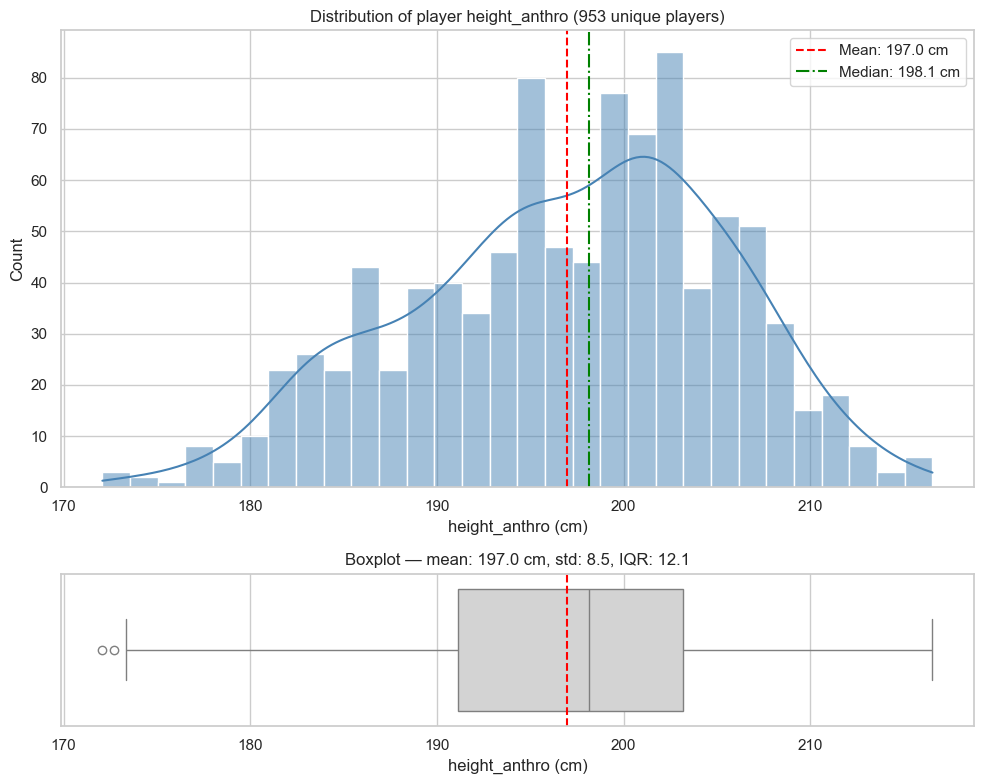

HEIGHT_ANTHRO — Count: 953, Mean: 197.0 cm, Median: 198.1 cm, Std: 8.5, IQR: 12.1
Outliers supérieurs:
Empty DataFrame
Columns: [keyfactor, Player, height_anthro, Season]
Index: []
Outliers inférieurs:
      keyfactor         Player  height_anthro       Season
865         865  Cordell Henry         172.72  2007 - 2008
503         503  Nate Robinson         172.08  2005 - 2006
991         991  Nate Robinson         172.08  2007 - 2008
1278       1278  Nate Robinson         172.08  2008 - 2009
1647       1647  Nate Robinson         172.08  2009 - 2010
1708       1708  Nate Robinson         172.08  2009 - 2010
2744       2744  Nate Robinson         172.08  2012 - 2013
2864       2864  Nate Robinson         172.08  2012 - 2013


In [24]:
# appel de la fonction pour la taille des joueurs
plot_player_distribution(merged, player_col='Player', value_col='height_anthro', unit='cm')

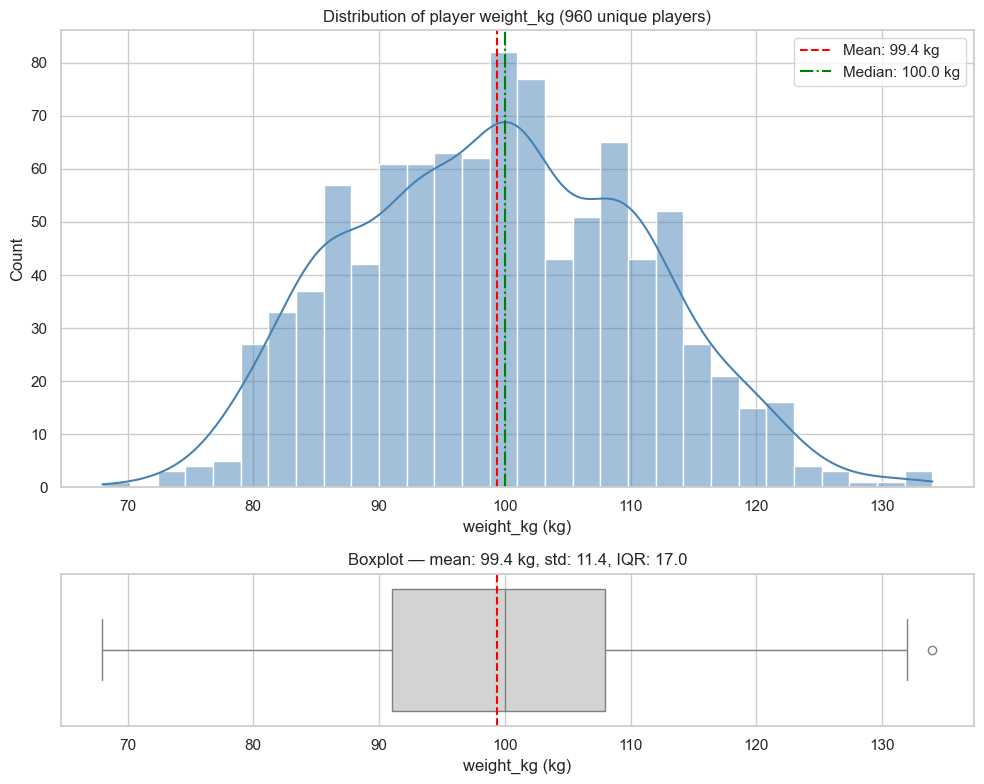

WEIGHT_KG — Count: 960, Mean: 99.4 kg, Median: 100.0 kg, Std: 11.4, IQR: 17.0
Outliers supérieurs:
      keyfactor      Player  weight_kg       Season
25           25  Eddy Curry      134.0  2001 - 2002
63           63  Eddy Curry      134.0  2002 - 2003
157         157  Eddy Curry      134.0  2003 - 2004
479         479  Eddy Curry      134.0  2005 - 2006
708         708  Eddy Curry      134.0  2006 - 2007
2572       2572  Eddy Curry      134.0  2012 - 2013
Outliers inférieurs:
Empty DataFrame
Columns: [keyfactor, Player, weight_kg, Season]
Index: []


In [25]:
# appel de la fonction pour le poids des joueurs
plot_player_distribution(merged, player_col='Player', value_col='weight_kg', unit='kg')

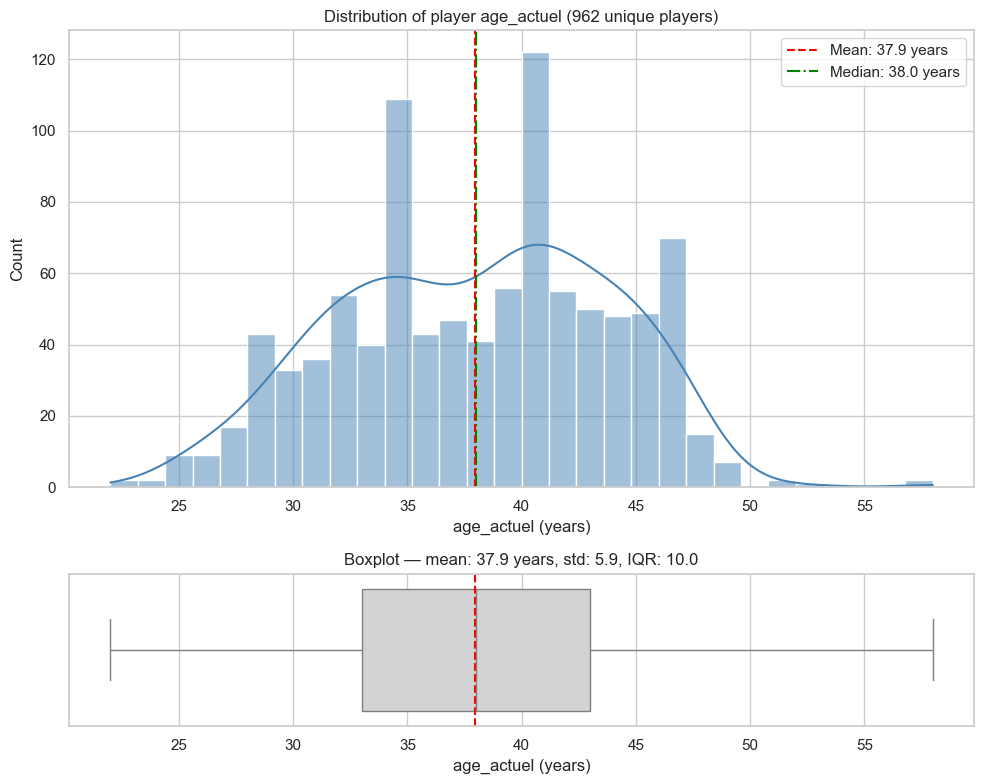

AGE_ACTUEL — Count: 962, Mean: 37.9 years, Median: 38.0 years, Std: 5.9, IQR: 10.0
Outliers supérieurs:
Empty DataFrame
Columns: [keyfactor, Player, age_actuel, Season]
Index: []
Outliers inférieurs:
Empty DataFrame
Columns: [keyfactor, Player, age_actuel, Season]
Index: []


In [26]:
# appel de la fonction pour l'âge des joueurs
plot_player_distribution(merged, player_col='Player', value_col='age_actuel', unit='years')

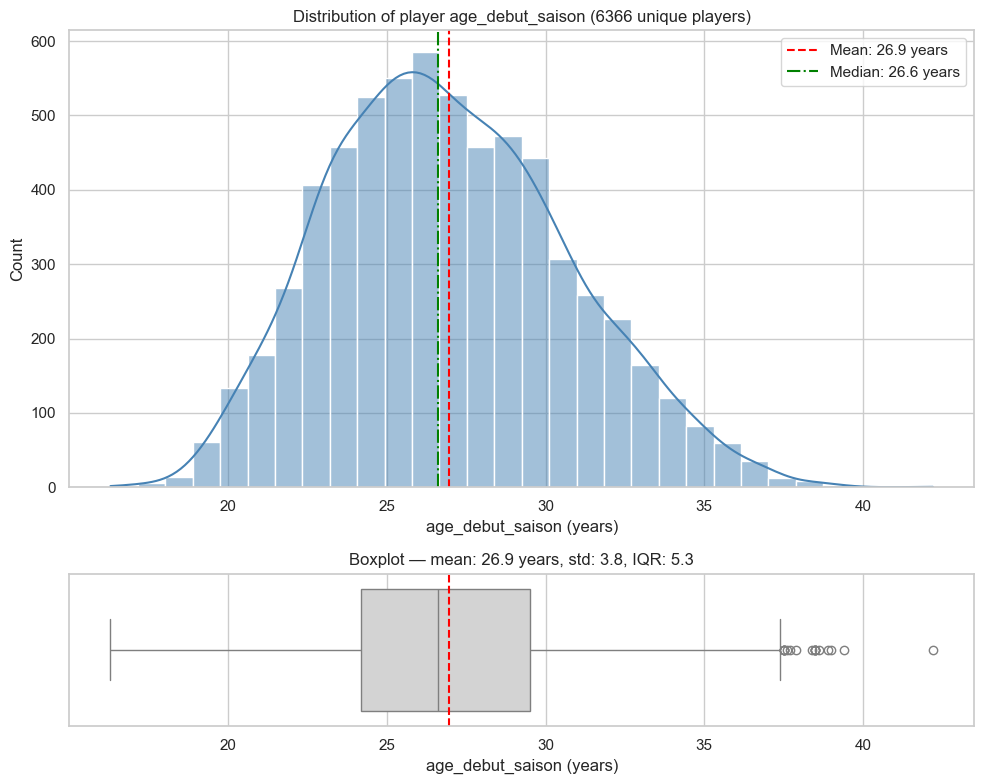

AGE_DEBUT_SAISON — Count: 6366, Mean: 26.9 years, Median: 26.6 years, Std: 3.8, IQR: 5.3
Outliers supérieurs:
      keyfactor            Player  age_debut_saison       Season
4817       4817  Immanuel McElroy              37.5  2017 - 2018
4920       4920  Immanuel McElroy              37.5  2017 - 2018
5055       5055    Jamal Crawford              37.5  2017 - 2018
5235       5235    Jamal Crawford              37.5  2017 - 2018
5604       5604       Kyle Korver              37.5  2018 - 2019
6010       6010     Travis Diener              37.6  2019 - 2020
6338       6338         Omar Cook              37.7  2019 - 2020
5955       5955      J.P. Batista              37.9  2019 - 2020
5317       5317        Sam Clancy              38.4  2018 - 2019
5625       5625    Jamal Crawford              38.5  2018 - 2019
5324       5324  Immanuel McElroy              38.5  2018 - 2019
5430       5430  Immanuel McElroy              38.5  2018 - 2019
6192       6192       Kyle Korver            

In [27]:
# appel de la fonction pour l'âge des joueurs quand ils jouaient
plot_player_distribution(merged, player_col='keyfactor', value_col='age_debut_saison', unit='years')

1.09
0.0
0.4758718190386429


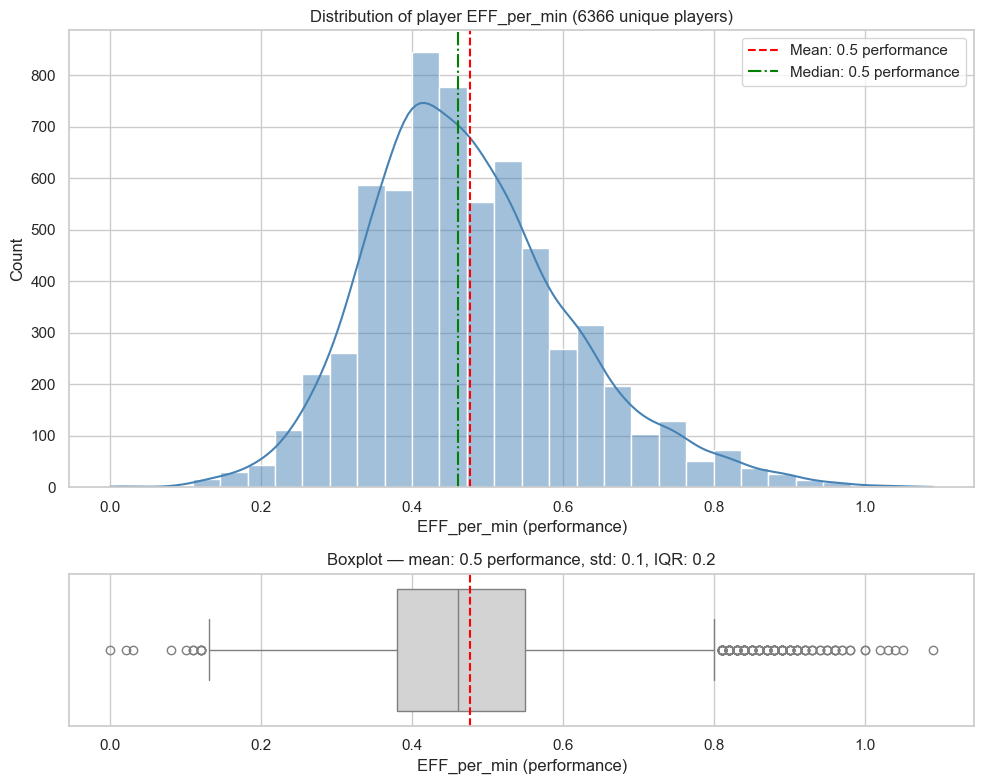

EFF_PER_MIN — Count: 6366, Mean: 0.5 performance, Median: 0.5 performance, Std: 0.1, IQR: 0.2
Outliers supérieurs:
      keyfactor             Player  EFF_per_min       Season
5489       5489       Kevin Durant         0.81  2018 - 2019
2691       2691        Loren Woods         0.81  2012 - 2013
4768       4768        David Simon         0.81  2016 - 2017
3607       3607  Russell Westbrook         0.81  2014 - 2015
5010       5010     Andre Drummond         0.81  2017 - 2018
...         ...                ...          ...          ...
5509       5509      Anthony Davis         1.02  2018 - 2019
5859       5859   Tyler Hansbrough         1.03  2019 - 2020
5347       5347       Cole Aldrich         1.04  2018 - 2019
4835       4835    Jamaal Franklin         1.05  2017 - 2018
5853       5853     Dakari Johnson         1.09  2019 - 2020

[145 rows x 4 columns]
Outliers inférieurs:
      keyfactor            Player  EFF_per_min       Season
385         385  Brian Scalabrine         0.12  

In [28]:
print(merged['EFF_per_min'].max())
print(merged['EFF_per_min'].min())
print(merged['EFF_per_min'].mean())
plot_player_distribution(merged, player_col='keyfactor', value_col='EFF_per_min', unit='performance')

In [29]:
import statsmodels.api as sm
import pandas as pd

def regression_lineaire(df, cible, variables):
    """
    Effectue une régression linéaire avec statsmodels.

    Paramètres
    ----------
    df : pd.DataFrame
        Ton DataFrame complet.
    cible : str
        Nom de la variable dépendante (y).
    variables : list
        Liste des variables explicatives (X).
    
    Retour
    ------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Le modèle ajusté.
    """
    # Vérifie la présence des colonnes
    colonnes = [cible] + variables
    data = df[colonnes].dropna()
    
    # Définition des variables
    X = data[variables]
    y = data[cible]
    
    # Ajout de la constante
    X = sm.add_constant(X)
    
    # Modèle
    model = sm.OLS(y, X).fit()
    
    # Affichage synthétique
    print("📊 RÉGRESSION LINÉAIRE POUR VOUS MON SEIGNEUR")
    print(f"Variable dépendante : {cible}")
    print(f"Variables explicatives : {', '.join(variables)}\n")
    print(model.summary())
    
    return model


In [30]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['height_anthro'])

📊 RÉGRESSION LINÉAIRE POUR VOUS MON SEIGNEUR
Variable dépendante : EFF_per_min
Variables explicatives : height_anthro

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     211.0
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           1.70e-46
Time:                        19:59:23   Log-Likelihood:                 2132.4
No. Observations:                3588   AIC:                            -4261.
Df Residuals:                    3586   BIC:                            -4248.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------

In [31]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['wingspan'])

📊 RÉGRESSION LINÉAIRE POUR VOUS MON SEIGNEUR
Variable dépendante : EFF_per_min
Variables explicatives : wingspan

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     353.2
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           3.07e-75
Time:                        19:59:23   Log-Likelihood:                 2200.5
No. Observations:                3593   AIC:                            -4397.
Df Residuals:                    3591   BIC:                            -4385.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------

In [32]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['weight_kg'])


📊 RÉGRESSION LINÉAIRE POUR VOUS MON SEIGNEUR
Variable dépendante : EFF_per_min
Variables explicatives : weight_kg

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     384.6
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           1.88e-81
Time:                        19:59:23   Log-Likelihood:                 2221.0
No. Observations:                3603   AIC:                            -4438.
Df Residuals:                    3601   BIC:                            -4426.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------

In [33]:
regression_lineaire(merged_NBA, 'EFF_per_min', ['age_debut_saison'])


📊 RÉGRESSION LINÉAIRE POUR VOUS MON SEIGNEUR
Variable dépendante : EFF_per_min
Variables explicatives : age_debut_saison

                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.03160
Date:                Mon, 17 Nov 2025   Prob (F-statistic):              0.859
Time:                        19:59:23   Log-Likelihood:                 2038.2
No. Observations:                3603   AIC:                            -4072.
Df Residuals:                    3601   BIC:                            -4060.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---

In [34]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# --- 0. Chargement du dataset et préparation ---
file_path = 'merged_NBA.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Erreur: Le fichier {file_path} n'a pas été trouvé.")
    exit()

# 1. Détermination et renommage des colonnes (basé sur la vérification finale)
df.rename(columns={
    'age_debut_saison': 'Age_of_Player',
    'height_anthro': 'Height_cm', # Utilisation du nom le plus probable basé sur le listage des colonnes
    'weight_kg': 'Weight_kg'
}, inplace=True)

# Conversion des colonnes en numérique
df['Age_of_Player'] = pd.to_numeric(df['Age_of_Player'], errors='coerce')
df['Height_cm'] = pd.to_numeric(df['Height_cm'], errors='coerce')
df['Weight_kg'] = pd.to_numeric(df['Weight_kg'], errors='coerce')



# 3. Filtrage pour un modèle stable: Saison Régulière et observations robustes
df_model = df[df['Stage'] == 'Regular_Season'].copy()
df_model = df_model[df_model['MIN'] >= 100].copy()

# Nettoyage final des variables du modèle
model_vars = ['EFF_per_min','Height_cm', 'Weight_kg', 'Age_of_Player']
df_model.dropna(subset=model_vars, inplace=True)


# 4. Définition et exécution du modèle de régression (avec modération: Taille * Âge)
formula = 'EFF_per_min ~ Height_cm + Weight_kg + Age_of_Player + Height_cm:Age_of_Player'
model = smf.ols(formula=formula, data=df_model).fit()

# 5. Affichage du résumé
print("--- Résultat de la Régression Linéaire Multiple (EFF_per_min vs Profil) ---")
print("Modèle: EFF_per_min = B0 + B1*Taille + B2*Poids + B3*Âge + B4*(Taille * Âge)")
print(model.summary())

--- Résultat de la Régression Linéaire Multiple (EFF_per_min vs Profil) ---
Modèle: EFF_per_min = B0 + B1*Taille + B2*Poids + B3*Âge + B4*(Taille * Âge)
                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     75.98
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           1.66e-60
Time:                        19:59:23   Log-Likelihood:                 1578.9
No. Observations:                2258   AIC:                            -3148.
Df Residuals:                    2253   BIC:                            -3119.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t 

In [35]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# --- 0. Chargement du dataset et préparation ---
file_path = 'merged_NBA.csv'
df = pd.read_csv(file_path)

# 1. Détermination et renommage des colonnes (basé sur la vérification)
# Renommage et conversion en numérique
df.rename(columns={
    'age_debut_saison': 'Age_of_Player',
    'height_anthro': 'Height_cm',
    'weight_kg': 'Weight_kg'
}, inplace=True)

df['Age_of_Player'] = pd.to_numeric(df['Age_of_Player'], errors='coerce')
df['Height_cm'] = pd.to_numeric(df['Height_cm'], errors='coerce')
df['Weight_kg'] = pd.to_numeric(df['Weight_kg'], errors='coerce')


# 2. Simplification et Nettoyage de la Position
# Prendre la position principale et remplacer les NaN par 'Unknown' temporairement
df['Simplified_Position'] = df['position'].str.split('/').str[0].fillna('Unknown')

# Re-simplification pour les 5 positions principales
df['Simplified_Position'] = df['Simplified_Position'].apply(lambda x: x.upper() if x in ['PG', 'SG', 'SF', 'PF', 'C'] else x)
# Nettoyage des positions composées résiduelles (e.g., 'C/PF' devient 'C')
df['Simplified_Position'] = df['Simplified_Position'].apply(lambda x: x[0] if len(x) > 1 and x[1] == '/' else x)
df['Simplified_Position'].replace('PF', 'PF', inplace=True) # Assurer la normalisation



# 3. Filtrage pour un modèle stable: Saison Régulière et observations robustes
df_model = df[df['Stage'] == 'Regular_Season'].copy()
df_model = df_model[df_model['MIN'] >= 100].copy()

# Nettoyage final des variables du modèle (incluant la position simplifiée)
model_vars = ['EFF_per_min', 'Height_cm', 'Weight_kg', 'Age_of_Player', 'Simplified_Position']
df_model.dropna(subset=model_vars, inplace=True)
# Retirer la catégorie 'Unknown' (seulement 11 lignes) si elle existe pour la rendre plus propre
df_model = df_model[df_model['Simplified_Position'] != 'Unknown'].copy()


# 4. Définition et exécution du modèle de régression (avec modération et Position)
formula = 'EFF_per_min ~ Height_cm + Weight_kg + Age_of_Player + Height_cm:Age_of_Player + C(Simplified_Position)'
model = smf.ols(formula=formula, data=df_model).fit()

# 5. Affichage du résumé
print("--- Résultat de la Régression Linéaire Multiple (EFF_per_min vs Profil + Position) ---")
print("Modèle: EFF_per_min = f(Taille, Poids, Âge, Taille * Âge, Position)")
print(model.summary())

--- Résultat de la Régression Linéaire Multiple (EFF_per_min vs Profil + Position) ---
Modèle: EFF_per_min = f(Taille, Poids, Âge, Taille * Âge, Position)
                            OLS Regression Results                            
Dep. Variable:            EFF_per_min   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     64.36
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           3.54e-95
Time:                        19:59:23   Log-Likelihood:                 1661.9
No. Observations:                2251   AIC:                            -3306.
Df Residuals:                    2242   BIC:                            -3254.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                   coef    std err     

C:\Users\J-P\AppData\Local\Temp\ipykernel_28968\3528352031.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Simplified_Position'].replace('PF', 'PF', inplace=True) # Assurer la normalisation


Bien que les facteurs physiques n'expliquent qu'une petite partie de la variance totale ($\mathbf{R^2}$ Ajusté $\mathbf{= 4.5\%}$), ils sont significatifs. La performance ($\text{EFF/min}$) est principalement déterminée par le Poids et la Position du joueur, l'expérience étant plus bénéfique pour l'efficacité des joueurs de petite taille.

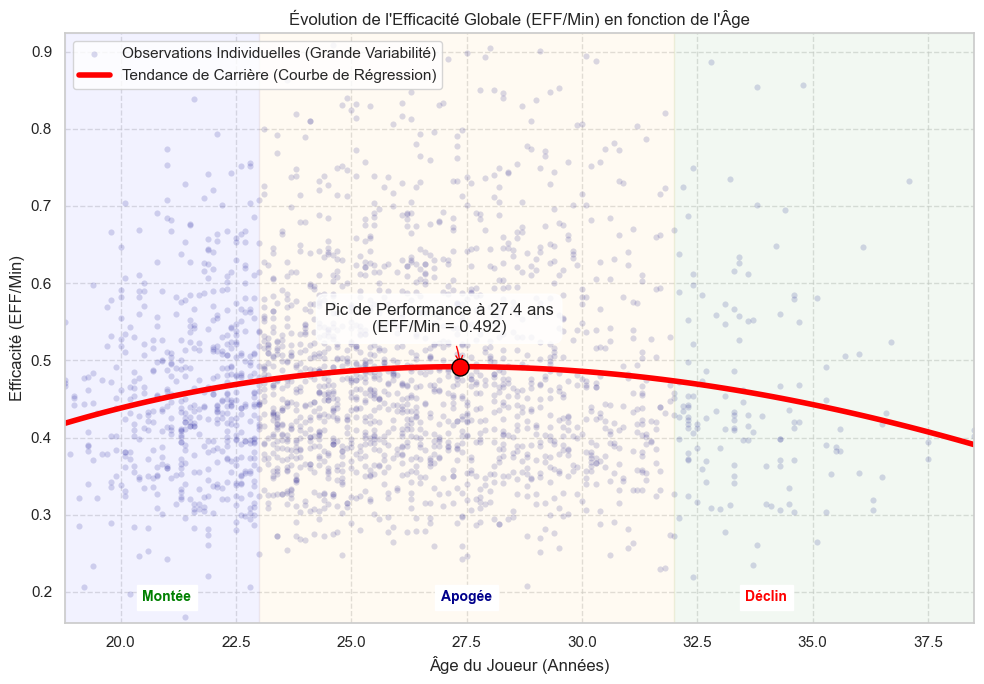

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 0. Chargement du dataset et préparation ---
file_path = 'merged_NBA.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Erreur: Le fichier {file_path} n'a pas été trouvé. Utilisation de la copie locale.")
    df = pd.read_csv('merged_NBA.csv')

# Détermination de la colonne d'âge
age_col = 'Age'
if 'age_debut_saison' in df.columns:
    age_col = 'age_debut_saison'

df[age_col] = pd.to_numeric(df[age_col], errors='coerce')

# Calcul de l'EFF par minute (EFF/Min)
required_cols = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'FGA', 'FGM', 'FTA', 'FTM', 'TOV', 'MIN']
positive_stats = df['PTS'] + df['REB'] + df['AST'] + df['STL'] + df['BLK']
negative_stats = (df['FGA'] - df['FGM']) + (df['FTA'] - df['FTM']) + df['TOV']
df['EFF_Total'] = positive_stats - negative_stats
df['MIN_safe'] = df['MIN'].replace(0, np.nan)
df['EFF_per_min'] = df['EFF_Total'] / df['MIN_safe']

# --- 1. Filtrage des joueurs multi-saisons et nettoyage ---
player_season_counts = df.groupby('Player')['Season'].nunique()
multi_season_players = player_season_counts[player_season_counts > 1].index

df_analysis = df[df['Player'].isin(multi_season_players)].copy()
df_analysis = df_analysis[df_analysis['MIN'] >= 100].copy()

df_reg_season_eff = df_analysis[df_analysis['Stage'] == 'Regular_Season'].copy()
df_reg_season_eff.dropna(subset=[age_col, 'EFF_per_min'], inplace=True)


# --- 2. Détermination du pic de performance (régression polynomiale) ---
coeffs = np.polyfit(df_reg_season_eff[age_col], df_reg_season_eff['EFF_per_min'], 3)
poly = np.poly1d(coeffs)

age_min = df_reg_season_eff[age_col].min()
age_max = df_reg_season_eff[age_col].max()
age_range = np.linspace(age_min, age_max, 100)
predicted_eff = poly(age_range)

peak_index = np.argmax(predicted_eff)
peak_age = age_range[peak_index]
peak_eff = predicted_eff[peak_index]
peak_age_rounded = round(peak_age, 1)


# --- 3. Visualisation combinée (Dispersion + Tendance + Annotations) ---
plt.figure(figsize=(10, 7))

# A. Scatter plot de tous les points (Montre la grande variabilité)
sns.scatterplot(
    data=df_reg_season_eff,
    x=age_col,
    y='EFF_per_min',
    alpha=0.15,
    color='darkblue',
    s=20,
    label='Observations Individuelles (Grande Variabilité)'
)

# B. Courbe de Tendance Polynomiale (Montre l'évolution)
plt.plot(
    age_range,
    predicted_eff,
    color='red',
    linestyle='-',
    linewidth=4,
    label='Tendance de Carrière (Courbe de Régression)'
)

# C. Annotation du Pic de Performance
plt.scatter(
    peak_age,
    peak_eff,
    color='red',
    s=150,
    zorder=5,
    edgecolor='black'
)
plt.annotate(
    f"Pic de Performance à {peak_age_rounded} ans\n(EFF/Min = {peak_eff:.3f})",
    (peak_age, peak_eff),
    textcoords="offset points",
    xytext=(-15, 25),
    ha='center',
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2", color='red'),
    bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8)
)

# D. Détermination de la position Y basse
y_pos_low = df_reg_season_eff['EFF_per_min'].min() + 0.02

# E. Annotation des Zones de Carrière (Labels en bas du graphique)
plt.axvspan(age_min, 23, color='blue', alpha=0.05)
plt.text(21, y_pos_low, 'Montée', color='green', ha='center', fontsize=10, weight='bold', backgroundcolor='white')

plt.axvspan(32, age_max, color='green', alpha=0.05)
plt.text(34, y_pos_low, 'Déclin', color='red', ha='center', fontsize=10, weight='bold', backgroundcolor='white')

plt.axvspan(23, 32, color='orange', alpha=0.05)
plt.text(27.5, y_pos_low, 'Apogée', color='darkblue', ha='center', fontsize=10, weight='bold', backgroundcolor='white')


plt.title('Évolution de l\'Efficacité Globale (EFF/Min) en fonction de l\'Âge')
plt.xlabel('Âge du Joueur (Années)')
plt.ylabel('Efficacité (EFF/Min)')
plt.xlim(age_min, age_max)
plt.ylim(df_reg_season_eff['EFF_per_min'].min() * 0.95, df_reg_season_eff['EFF_per_min'].quantile(0.99) * 1.1)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# sauvegarde du graphique
plt.savefig('evolution_efficiency_age.png', dpi=300, bbox_inches="tight")

# --- COMMANDE POUR AFFICHER LE GRAPHIQUE INTERACTIVEMENT DANS VOTRE ENVIRONNEMENT ---
plt.show()

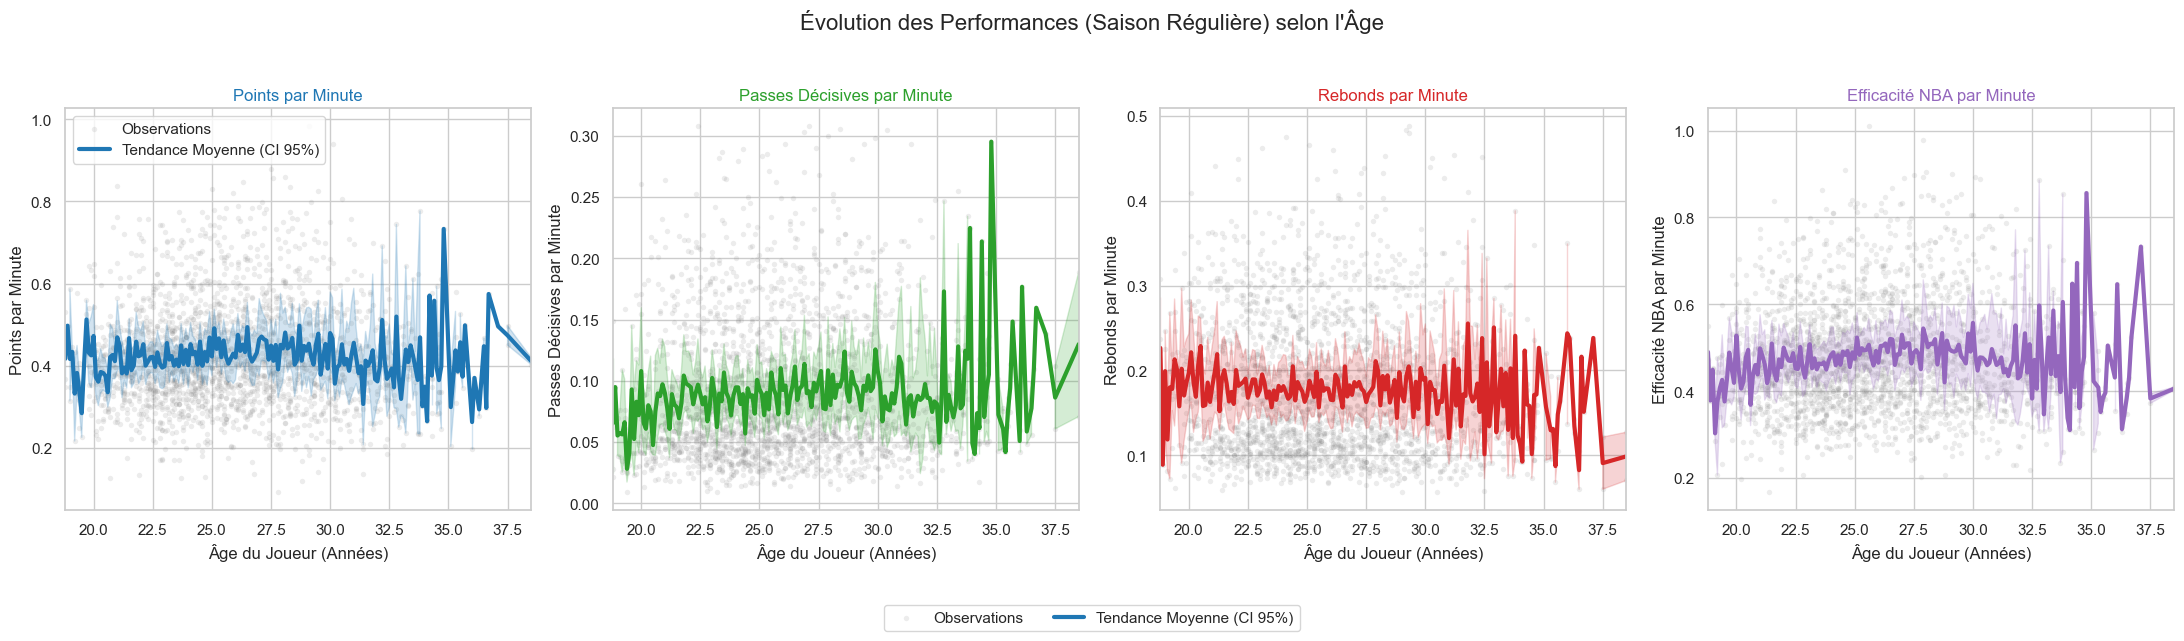

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 0. Chargement du dataset et préparation ---
file_path = 'merged_NBA.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Erreur: Le fichier {file_path} n'a pas été trouvé. Veuillez vérifier le chemin.")
    df = pd.read_csv('merged_NBA.csv') # Tentative de chargement local

# Détermination de la colonne d'âge
age_col = None
if 'Age' in df.columns:
    age_col = 'Age'
elif 'age_debut_saison' in df.columns:
    age_col = 'age_debut_saison'
else:
    print("Erreur critique: La colonne d'âge est introuvable.")
    exit()

# Conversion de l'âge en numérique
df[age_col] = pd.to_numeric(df[age_col], errors='coerce')

# --- 1. Calcul des Métriques d'Efficacité (Per Minute) ---

# 1.1. Efficacité (EFF) Totale selon la formule NBA
# EFF = (PTS+REB+AST+STL+BLK) - ((FGA−FGM)+(FTA−FTM)+TOV)
required_cols = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'FGA', 'FGM', 'FTA', 'FTM', 'TOV', 'MIN']
if not all(col in df.columns for col in required_cols):
    print("Erreur: Colonnes de statistiques manquantes pour calculer l'Efficacité (EFF).")
    exit()

positive_stats = df['PTS'] + df['REB'] + df['AST'] + df['STL'] + df['BLK']
negative_stats = (df['FGA'] - df['FGM']) + (df['FTA'] - df['FTM']) + df['TOV']
df['EFF_Total'] = positive_stats - negative_stats

# 1.2. Calcul des métriques par minute
df['MIN_safe'] = df['MIN'].replace(0, np.nan)
df['PTS_per_min'] = df['PTS'] / df['MIN_safe']
df['AST_per_min'] = df['AST'] / df['MIN_safe']
df['REB_per_min'] = df['REB'] / df['MIN_safe']
df['EFF_per_min'] = df['EFF_Total'] / df['MIN_safe'] # La métrique d'efficacité demandée


# --- 2. Filtrage des joueurs multi-saisons et nettoyage ---
player_season_counts = df.groupby('Player')['Season'].nunique()
multi_season_players = player_season_counts[player_season_counts > 1].index

df_analysis = df[df['Player'].isin(multi_season_players)].copy()
df_analysis = df_analysis[df_analysis['MIN'] >= 100].copy()

# Utiliser uniquement la Saison Régulière pour la courbe de carrière stable
df_reg_season_age = df_analysis[df_analysis['Stage'] == 'Regular_Season'].copy()
df_reg_season_age.dropna(subset=[age_col, 'PTS_per_min', 'AST_per_min', 'REB_per_min', 'EFF_per_min'], inplace=True)


# --- 3. Visualisation : Évolution des 4 performances selon l'Âge ---
metrics_to_plot = {
    'PTS_per_min': 'Points par Minute',
    'AST_per_min': 'Passes Décisives par Minute',
    'REB_per_min': 'Rebonds par Minute',
    'EFF_per_min': 'Efficacité NBA par Minute' # La métrique demandée
}

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharex=True)
fig.suptitle("Évolution des Performances (Saison Régulière) selon l'Âge", fontsize=16)

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd'] # Bleu, Vert, Rouge, Violet

for i, (metric, title) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    color = colors[i]

    df_plot = df_reg_season_age.dropna(subset=[metric])

    # 1. Scatter plot de tous les points (Montre la variabilité)
    sns.scatterplot(
        data=df_plot,
        x=age_col,
        y=metric,
        alpha=0.15,
        color='gray',
        s=15,
        ax=ax,
        label='Observations' if i == 0 else ""
    )

    # 2. Ligne de tendance moyenne avec intervalle de confiance
    sns.lineplot(
        data=df_plot,
        x=age_col,
        y=metric,
        estimator='mean',
        errorbar=('ci', 95), # Intervalle de confiance à 95%
        color=color,
        linewidth=3,
        label='Tendance Moyenne (CI 95%)' if i == 0 else "",
        ax=ax
    )

    ax.set_title(title, fontsize=12, color=color)
    ax.set_xlabel('Âge du Joueur (Années)')
    ax.set_ylabel(title)
    ax.set_xlim(df_plot[age_col].min(), df_plot[age_col].max())


# Ajouter une légende globale
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# sauvegarde du graphique
plt.savefig('evolution_performance_age.png', dpi=300, bbox_inches="tight")

# --- COMMANDE POUR AFFICHER LE GRAPHIQUE INTERACTIVEMENT ---
plt.show()

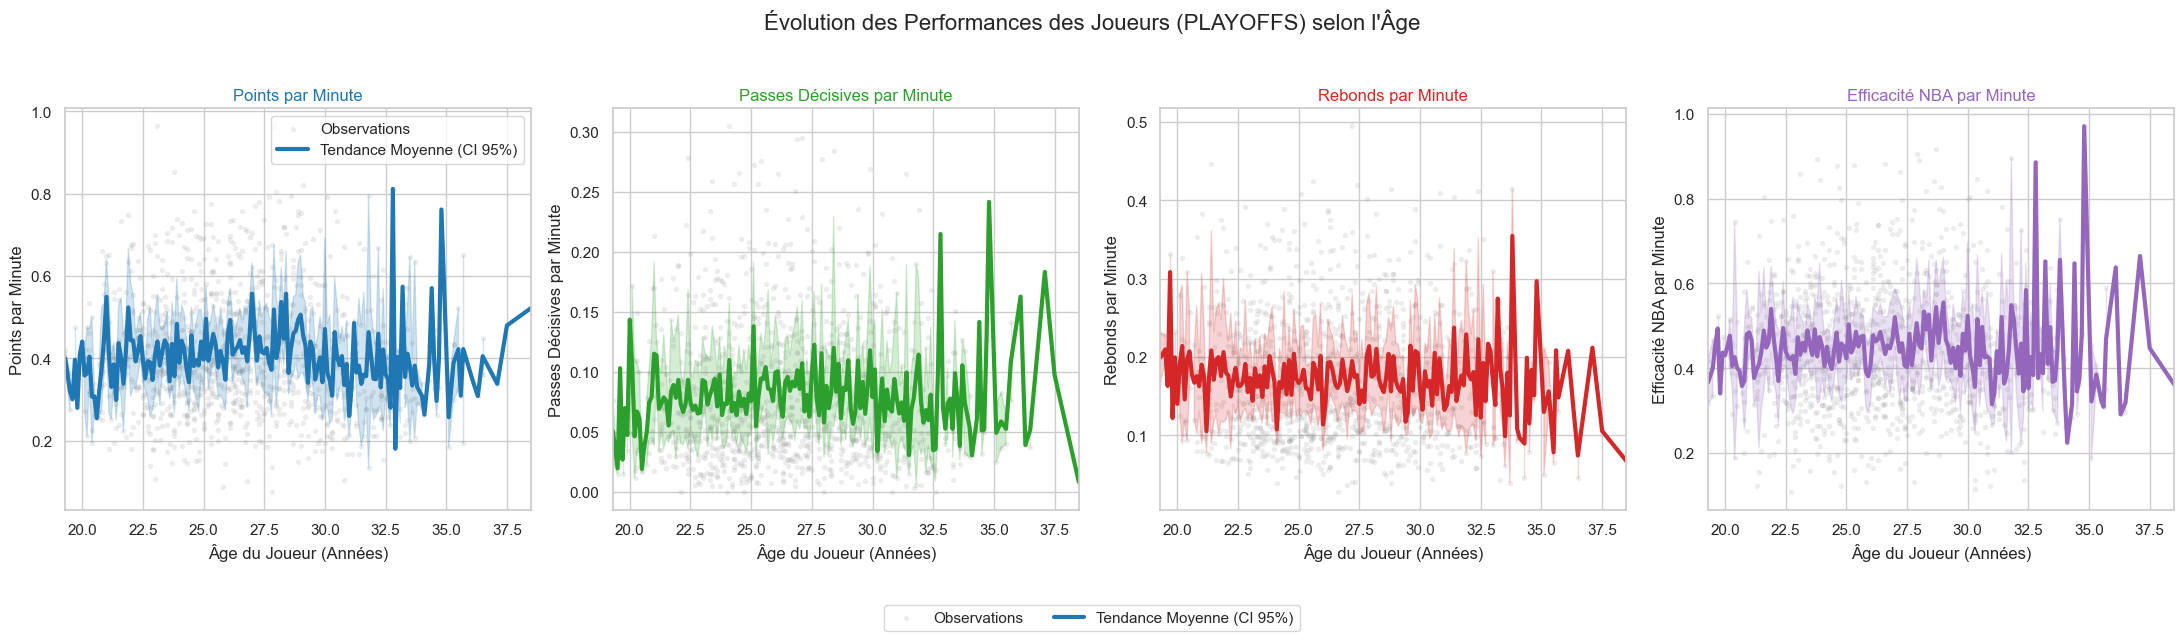

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 0. Chargement du dataset et préparation ---
file_path = 'merged_NBA.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Erreur: Le fichier {file_path} n'a pas été trouvé. Utilisation de la copie locale.")
    df = pd.read_csv('merged_NBA.csv')

# Détermination de la colonne d'âge
age_col = None
if 'Age' in df.columns:
    age_col = 'Age'
elif 'age_debut_saison' in df.columns:
    age_col = 'age_debut_saison'
else:
    print("Erreur critique: La colonne d'âge est introuvable. Arrêt de la visualisation.")
    exit()

# Conversion de l'âge en numérique
df[age_col] = pd.to_numeric(df[age_col], errors='coerce')

# Calcul des Métriques d'Efficacité (Per Minute)
required_cols = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'FGA', 'FGM', 'FTA', 'FTM', 'TOV', 'MIN']
positive_stats = df['PTS'] + df['REB'] + df['AST'] + df['STL'] + df['BLK']
negative_stats = (df['FGA'] - df['FGM']) + (df['FTA'] - df['FTM']) + df['TOV']
df['EFF_Total'] = positive_stats - negative_stats

df['MIN_safe'] = df['MIN'].replace(0, np.nan)
df['PTS_per_min'] = df['PTS'] / df['MIN_safe']
df['AST_per_min'] = df['AST'] / df['MIN_safe']
df['REB_per_min'] = df['REB'] / df['MIN_safe']
df['EFF_per_min'] = df['EFF_Total'] / df['MIN_safe']


# --- 1. Filtrage des joueurs multi-saisons et nettoyage ---
player_season_counts = df.groupby('Player')['Season'].nunique()
multi_season_players = player_season_counts[player_season_counts > 1].index

df_analysis = df[df['Player'].isin(multi_season_players)].copy()
df_analysis = df_analysis[df_analysis['MIN'] >= 100].copy()

# Filtrage CLÉ pour les PLAYOFFS
df_playoffs_age = df_analysis[df_analysis['Stage'] == 'Playoffs'].copy()
df_playoffs_age.dropna(subset=[age_col, 'PTS_per_min', 'AST_per_min', 'REB_per_min', 'EFF_per_min'], inplace=True)


# --- 2. Visualisation : Évolution des 4 performances selon l'Âge (PLAYOFFS) ---
metrics_to_plot = {
    'PTS_per_min': 'Points par Minute',
    'AST_per_min': 'Passes Décisives par Minute',
    'REB_per_min': 'Rebonds par Minute',
    'EFF_per_min': 'Efficacité NBA par Minute'
}

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharex=True)
fig.suptitle("Évolution des Performances des Joueurs (PLAYOFFS) selon l'Âge", fontsize=16)

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']

for i, (metric, title) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    color = colors[i]

    df_plot = df_playoffs_age.dropna(subset=[metric])

    # 1. Scatter plot de tous les points (Montre la variabilité)
    sns.scatterplot(
        data=df_plot,
        x=age_col,
        y=metric,
        alpha=0.15,
        color='gray',
        s=15,
        ax=ax,
        label='Observations' if i == 0 else ""
    )

    # 2. Ligne de tendance moyenne avec intervalle de confiance
    # Note: Utilisation de la méthode de ligne de tendance pour capturer la courbe de carrière.
    sns.lineplot(
        data=df_plot,
        x=age_col,
        y=metric,
        estimator='mean',
        errorbar=('ci', 95), # Intervalle de confiance à 95%
        color=color,
        linewidth=3,
        label='Tendance Moyenne (CI 95%)' if i == 0 else "",
        ax=ax
    )

    ax.set_title(title, fontsize=12, color=color)
    ax.set_xlabel('Âge du Joueur (Années)')
    ax.set_ylabel(title)
    ax.set_xlim(df_plot[age_col].min(), df_plot[age_col].max())


# Ajouter une légende globale
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# sauvegarde du graphique
plt.savefig('evolution_performance_age_playoffs.png', dpi=300, bbox_inches="tight")

# --- COMMANDE POUR AFFICHER LE GRAPHIQUE INTERACTIVEMENT ---
plt.show()

In [39]:
import pandas as pd
import numpy as np
from scipy import stats

# --- 0. Chargement du dataset et préparation ---
file_path = 'merged_NBA.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Erreur: Le fichier {file_path} n'a pas été trouvé. Utilisation de la copie locale.")
    df = pd.read_csv('merged_NBA.csv')

# Calcul des Métriques d'Efficacité (Per Minute)
required_cols = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'FGA', 'FGM', 'FTA', 'FTM', 'TOV', 'MIN']
if not all(col in df.columns for col in required_cols):
    print("Erreur: Colonnes de statistiques manquantes. Impossible de calculer toutes les métriques.")
    exit()

df['MIN_safe'] = df['MIN'].replace(0, np.nan)

# Métriques Offensives/Overall
df['PTS_per_min'] = df['PTS'] / df['MIN_safe']
df['AST_per_min'] = df['AST'] / df['MIN_safe']
df['REB_per_min'] = df['REB'] / df['MIN_safe']

# Métriques Défensives
df['STL_per_min'] = df['STL'] / df['MIN_safe']
df['BLK_per_min'] = df['BLK'] / df['MIN_safe']

# Métriques Négatives (Erreurs et Échecs au tir)
df['TOV_per_min'] = df['TOV'] / df['MIN_safe']
df['FGA_minus_FGM_per_min'] = (df['FGA'] - df['FGM']) / df['MIN_safe']
df['FTA_minus_FTM_per_min'] = (df['FTA'] - df['FTM']) / df['MIN_safe']

# Efficacité Totale (EFF) selon formule NBA
positive_stats = df['PTS'] + df['REB'] + df['AST'] + df['STL'] + df['BLK']
negative_stats_eff = (df['FGA'] - df['FGM']) + (df['FTA'] - df['FTM']) + df['TOV']
df['EFF_per_min'] = (positive_stats - negative_stats_eff) / df['MIN_safe']


# --- 1. Filtrage des joueurs multi-saisons et nettoyage ---
player_season_counts = df.groupby('Player')['Season'].nunique()
multi_season_players = player_season_counts[player_season_counts > 1].index

df_analysis = df[df['Player'].isin(multi_season_players)].copy()
df_analysis = df_analysis[df_analysis['MIN'] >= 100].copy() # Filtrage MIN >= 100


# --- 2. Test t de Student pour TOUTES les métriques ---
print("\n--- Synthèse du Test t (TOUTES les Statistiques : Playoffs vs. Saison Régulière) ---")

metrics_to_test = {
    'PTS_per_min': 'Points/min (Offense)',
    'AST_per_min': 'Assists/min (Offense)',
    'REB_per_min': 'Rebounds/min (Offense)',
    'EFF_per_min': 'EFF/min (Overall)',
    'STL_per_min': 'Steals/min (Defense)',
    'BLK_per_min': 'Blocks/min (Defense)',
    'TOV_per_min': 'Turnovers/min (Negative)',
    'FGA_minus_FGM_per_min': 'Missed FGs/min (Negative)',
    'FTA_minus_FTM_per_min': 'Missed FTs/min (Negative)'
}

results = {}
for metric, label in metrics_to_test.items():
    reg_season_data = df_analysis[df_analysis['Stage'] == 'Regular_Season'][metric].dropna()
    playoffs_data = df_analysis[df_analysis['Stage'] == 'Playoffs'][metric].dropna()

    if len(reg_season_data) > 1 and len(playoffs_data) > 1:
        t_stat, p_value = stats.ttest_ind(reg_season_data, playoffs_data, equal_var=False)
        results[label] = {
            'Moyenne Rég.': reg_season_data.mean(),
            'Moyenne Playoffs': playoffs_data.mean(),
            'Valeur p': p_value,
            'Statistique t': t_stat
        }

results_df = pd.DataFrame(results).T.round(4)
results_df['Significatif (p<0.05)'] = results_df['Valeur p'] < 0.05
print("Résultats des tests t de Student (Saison Régulière vs Playoffs) :")
print(results_df.sort_values(by='Valeur p'))
print("\nUne valeur p < 0.05 indique que la différence entre les deux moyennes est statistiquement significative.")
print("\n--- Interprétation de la Différence Statistique ---")
print("Les résultats du Test t démontrent que la baisse d'efficacité (EFF/min) et de production pour la majorité des métriques offensives et défensives est statistiquement significative en Playoffs.")
print("Cette tendance est expliquée par une intensité défensive et une rigueur stratégique accrues en séries éliminatoires, ce qui se traduit par une diminution du rythme de jeu et des possessions par minute, réduisant ainsi la fréquence de tous les événements statistiques (réussites comme erreurs) par unité de temps.")



--- Synthèse du Test t (TOUTES les Statistiques : Playoffs vs. Saison Régulière) ---
Résultats des tests t de Student (Saison Régulière vs Playoffs) :
                           Moyenne Rég.  Moyenne Playoffs  Valeur p  \
Assists/min (Offense)            0.0886            0.0803    0.0000   
EFF/min (Overall)                0.4775            0.4453    0.0000   
Steals/min (Defense)             0.0318            0.0299    0.0002   
Points/min (Offense)             0.4252            0.4080    0.0007   
Turnovers/min (Negative)         0.0556            0.0526    0.0007   
Rebounds/min (Offense)           0.1773            0.1705    0.0198   
Missed FTs/min (Negative)        0.0237            0.0252    0.0604   
Blocks/min (Defense)             0.0202            0.0194    0.2727   
Missed FGs/min (Negative)        0.1862            0.1849    0.5723   

                           Statistique t  Significatif (p<0.05)  
Assists/min (Offense)             4.0689                   True  
EFF/m

In [40]:
import pandas as pd
import numpy as np

# --- 0. Chargement du dataset et préparation (reprise des étapes nécessaires) ---
file_path = 'merged_NBA.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    df = pd.read_csv('merged_NBA.csv')

# Calcul de l'EFF/Min
required_stats = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'FGA', 'FGM', 'FTA', 'FTM', 'TOV', 'MIN']
positive_stats = df['PTS'] + df['REB'] + df['AST'] + df['STL'] + df['BLK']
negative_stats = (df['FGA'] - df['FGM']) + (df['FTA'] - df['FTM']) + df['TOV']
df['EFF_Total'] = positive_stats - negative_stats
df['MIN_safe'] = df['MIN'].replace(0, np.nan)
df['EFF_per_min'] = df['EFF_Total'] / df['MIN_safe']

# Filtrage pour l'analyse
df_robust = df[df['MIN'] >= 100].copy()


# --- 1. Calcul de l'EFF/min MOYENNE pour chaque joueur sur leur carrière Reg. Season ---
player_reg_season_mean = df_robust[df_robust['Stage'] == 'Regular_Season'].groupby('Player')['EFF_per_min'].mean().reset_index()
player_reg_season_mean.rename(columns={'EFF_per_min': 'Avg_EFF_Reg_Season'}, inplace=True)

# 2. Identifier les joueurs ÉLITES (Top 10% en EFF/Min Reg. Season)
# Calculer le seuil du 90e percentile
top_percentile = player_reg_season_mean['Avg_EFF_Reg_Season'].quantile(0.90)
elite_players = player_reg_season_mean[player_reg_season_mean['Avg_EFF_Reg_Season'] >= top_percentile]['Player']

print(f"Seuil du Top 10% d'efficacité (EFF/Min) en Saison Régulière : {top_percentile:.4f}")
print(f"Nombre de joueurs dans le groupe Élite : {len(elite_players)}")


# 3. Calculer le DIFFÉRENTIEL (Playoffs - Reg. Season) pour le groupe Élite
# Filtrer les performances de TOUS les joueurs (Reg. Season et Playoffs)
pivot_eff = df_robust.groupby(['Player', 'Stage'])['EFF_per_min'].mean().unstack().reset_index()
pivot_eff.rename(columns={'Regular_Season': 'Avg_EFF_Reg_Season_Full', 'Playoffs': 'Avg_EFF_Playoffs_Full'}, inplace=True)

# S'assurer que les joueurs ont joué dans les deux stages (Reg. Season et Playoffs)
pivot_eff.dropna(subset=['Avg_EFF_Reg_Season_Full', 'Avg_EFF_Playoffs_Full'], inplace=True)


# Filtrer le pivot UNIQUEMENT pour les joueurs élites identifiés à l'étape 2
elite_comparison = pivot_eff[pivot_eff['Player'].isin(elite_players)].copy()

# Calculer le différentiel
elite_comparison['EFF_DIFFERENTIAL'] = elite_comparison['Avg_EFF_Playoffs_Full'] - elite_comparison['Avg_EFF_Reg_Season_Full']

# 4. Afficher et Analyser les résultats
mean_elite_diff = elite_comparison['EFF_DIFFERENTIAL'].mean()
mean_elite_reg = elite_comparison['Avg_EFF_Reg_Season_Full'].mean()
mean_elite_po = elite_comparison['Avg_EFF_Playoffs_Full'].mean()

print("\n--- Analyse de l'Évolution des Joueurs Élites (Top 10% EFF/Min) ---")
print(f"Efficacité moyenne en Saison Régulière (Groupe Élite) : {mean_elite_reg:.4f}")
print(f"Efficacité moyenne en Playoffs (Groupe Élite) : {mean_elite_po:.4f}")
print(f"Différence Moyenne (Playoffs - Reg. Season) pour le Groupe Élite : {mean_elite_diff:.4f}")

if mean_elite_diff > 0:
    print("\nConclusion : Le groupe Élite montre une augmentation moyenne d'efficacité en Playoffs. Ils 'carrient' leur équipe.")
else:
    print("\nConclusion : Le groupe Élite montre une diminution moyenne d'efficacité en Playoffs, se conformant à la tendance générale, mais gère la pression mieux que la moyenne.")

# Afficher les 5 meilleurs différentiels au sein de ce groupe Élite
top_5_elite_specialists = elite_comparison.sort_values(by='EFF_DIFFERENTIAL', ascending=False).head(5)
print("\nTop 5 des joueurs Élite qui s'améliorent le plus en Playoffs:")
print(top_5_elite_specialists[['Player', 'Avg_EFF_Reg_Season_Full', 'Avg_EFF_Playoffs_Full', 'EFF_DIFFERENTIAL']].round(4))

Seuil du Top 10% d'efficacité (EFF/Min) en Saison Régulière : 0.6111
Nombre de joueurs dans le groupe Élite : 49

--- Analyse de l'Évolution des Joueurs Élites (Top 10% EFF/Min) ---
Efficacité moyenne en Saison Régulière (Groupe Élite) : 0.6870
Efficacité moyenne en Playoffs (Groupe Élite) : 0.6121
Différence Moyenne (Playoffs - Reg. Season) pour le Groupe Élite : -0.0749

Conclusion : Le groupe Élite montre une diminution moyenne d'efficacité en Playoffs, se conformant à la tendance générale, mais gère la pression mieux que la moyenne.

Top 5 des joueurs Élite qui s'améliorent le plus en Playoffs:
Stage         Player  Avg_EFF_Reg_Season_Full  Avg_EFF_Playoffs_Full  \
221    Jarrett Allen                   0.6650                 0.7276   
181      Greg Monroe                   0.6330                 0.6413   
279    Kawhi Leonard                   0.6666                 0.6677   
306     LeBron James                   0.7594                 0.7548   
200     JaVale McGee              